<a href="https://colab.research.google.com/github/Muhammad-ShahFahad/Customer_Churn_Prediction/blob/main/Customer_Churn_Pred.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATA SCIENCE PROJECT

Customer Churn Prediction

In [176]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.ensemble import StackingClassifier, BaggingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import pickle
import joblib
import warnings
warnings.filterwarnings('ignore')

Load Dataset

In [177]:
df = pd.read_excel('Telco_customer_churn.xlsx')

Understand the Dataset

In [178]:
df.head(5)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [179]:
df.shape

(7043, 33)

In [180]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [181]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [182]:
df.isnull().sum()

,0
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


In [183]:
df.duplicated().sum()

np.int64(0)

Data Cleaning

In [184]:
# Data type of Total Charges
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

In [185]:
# Checking Null in Total Charges
df['Total Charges'].isnull().sum()

np.int64(11)

In [186]:
# Dropping Unwanted Columns
df.drop(columns=['CustomerID', 'Count', 'Zip Code', 'Lat Long', 'Country', 'State', 'City'], inplace=True)

In [187]:
# Dropping Columns which might cause Data Leakage
df.drop(columns=['Churn Reason', 'Churn Score', 'CLTV', 'Churn Label'], inplace=True)

In [188]:
# Dropping Columns with little to no correlation
# from numeric cols
df.drop(columns=['Latitude', 'Longitude'], inplace=True)

In [189]:
# Dropping Columns after Chi Square Test
df.drop(columns=['Gender', 'Phone Service'], inplace=True)

In [190]:
# Dropping Columns after Cramer V test
df.drop(columns=['Multiple Lines'], inplace= True)

EDA- Exploratory Data Analysis

Target variable = Churn Value

<Axes: xlabel='Churn Value', ylabel='count'>

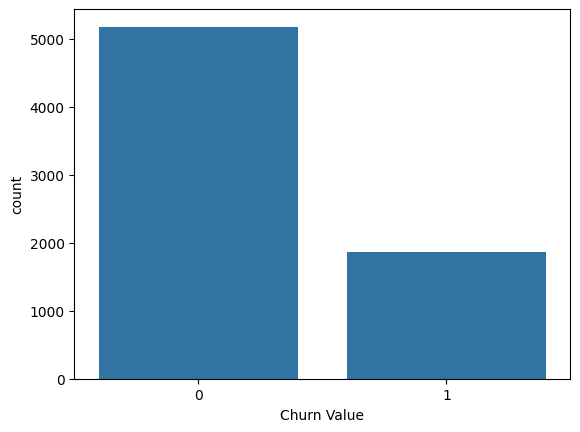

In [191]:
# Target Distribution
sns.countplot(x='Churn Value', data=df)

Tenure Months


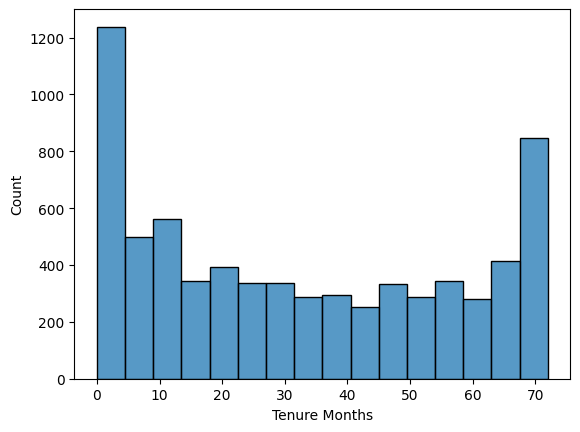

0.2395397495619829
Monthly Charges


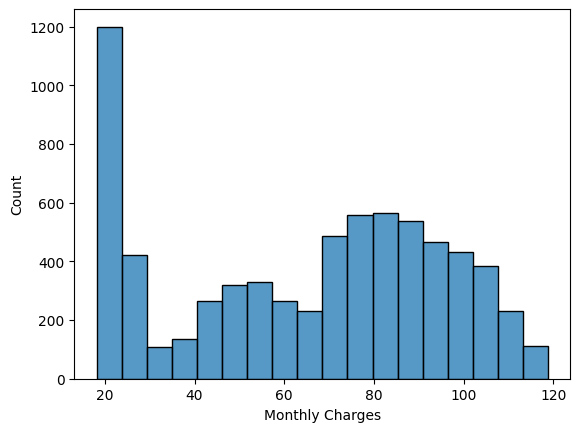

-0.22052443394398033
Total Charges


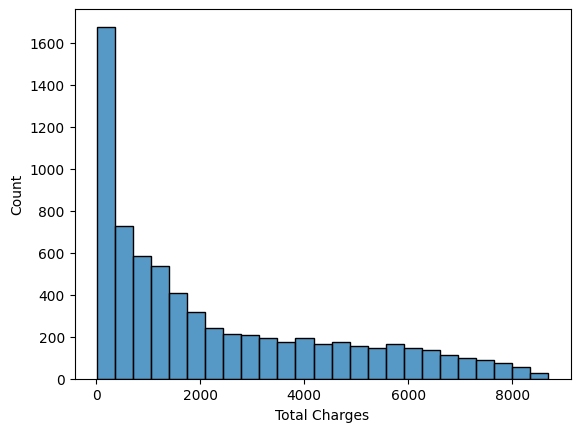

0.961642499724251
Churn Value


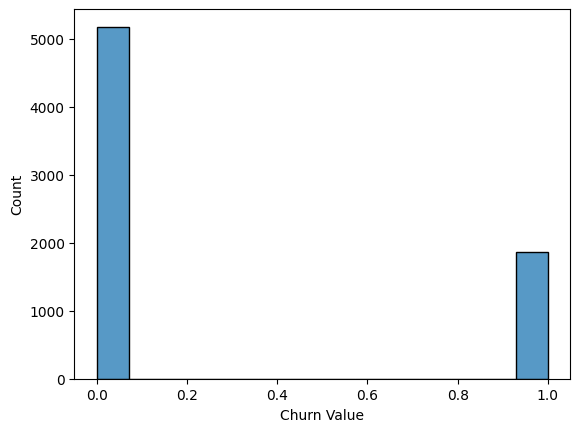

1.063031444575135


In [192]:
#  Numeric features Distribution
for col in df.select_dtypes(include='number'):
  print(col)
  sns.histplot(x=col, data=df)
  plt.show()
  print(df[col].skew())


Tenure Months


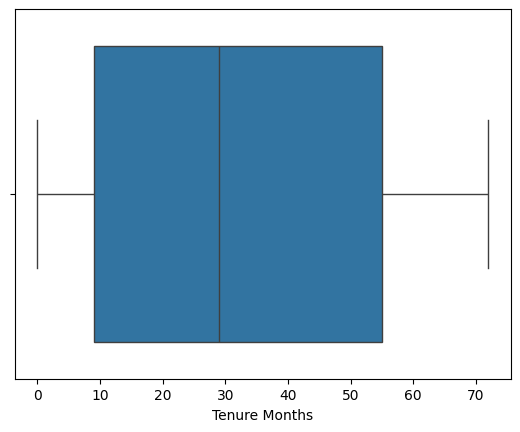

Monthly Charges


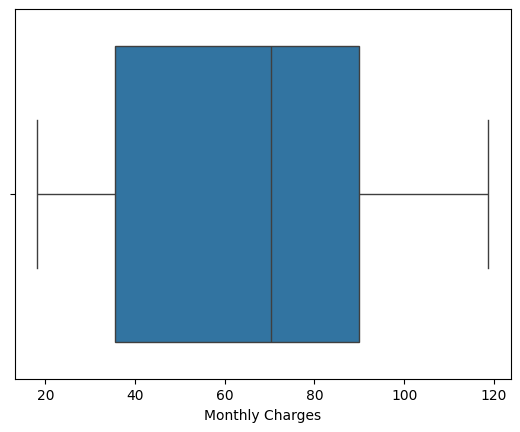

Total Charges


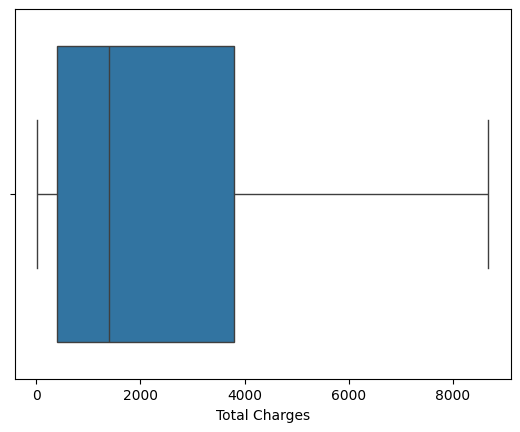

Churn Value


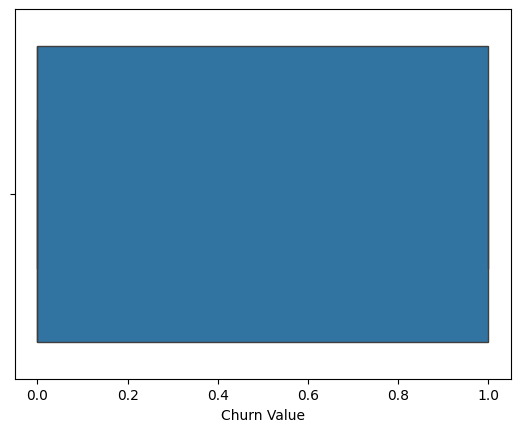

In [193]:
for col in df.select_dtypes(include='number'):
  print(col)
  sns.boxplot(x=col, data=df)
  plt.show()

<Axes: >

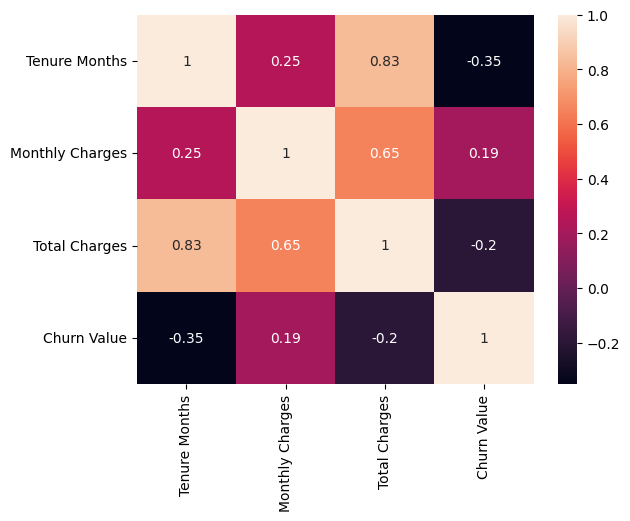

In [194]:
# Numeric Feature Correlation
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)

In [195]:
# Categorical Features
cat_features = df.select_dtypes(include='object').columns.tolist()

In [196]:
for col in cat_features:
  print(df[col].unique())

['No' 'Yes']
['No' 'Yes']
['No' 'Yes']
['DSL' 'Fiber optic' 'No']
['Yes' 'No' 'No internet service']
['Yes' 'No' 'No internet service']
['No' 'Yes' 'No internet service']
['No' 'Yes' 'No internet service']
['No' 'Yes' 'No internet service']
['No' 'Yes' 'No internet service']
['Month-to-month' 'Two year' 'One year']
['Yes' 'No']
['Mailed check' 'Electronic check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [197]:
# Fixing No Internet Service
addon_cols = ['Online Security', 'Online Backup', 'Device Protection',
              'Tech Support', 'Streaming TV', 'Streaming Movies']

for col in addon_cols:
    df[col] = df[col].replace({'No internet service': 'No'})

In [198]:
df[cat_features].nunique()

,0
Senior Citizen,2
Partner,2
Dependents,2
Internet Service,3
Online Security,2
Online Backup,2
Device Protection,2
Tech Support,2
Streaming TV,2
Streaming Movies,2


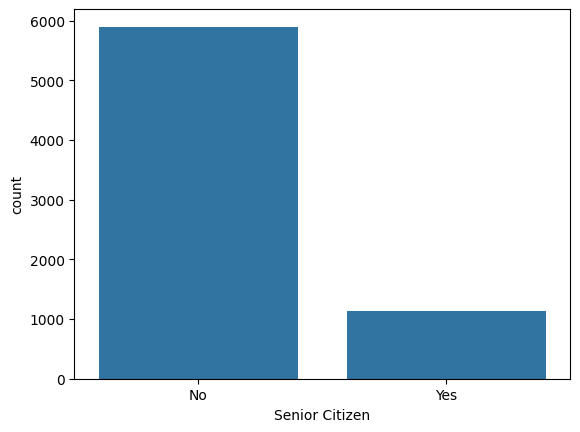

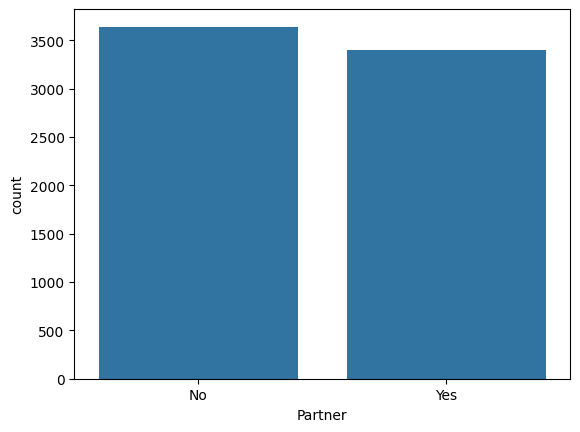

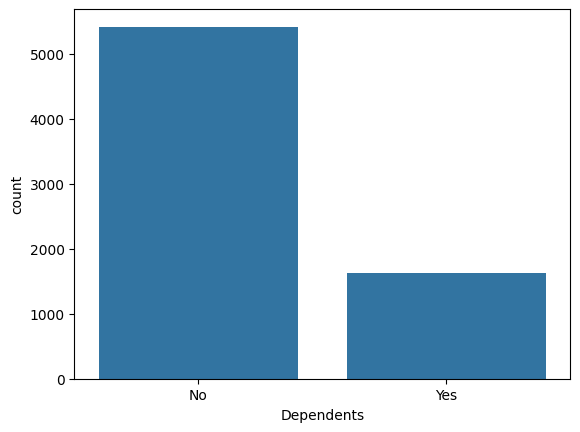

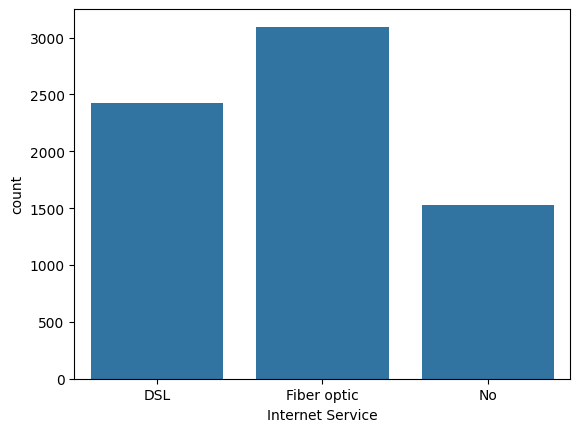

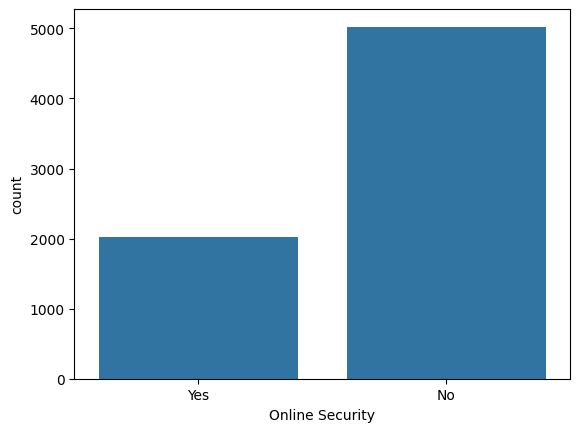

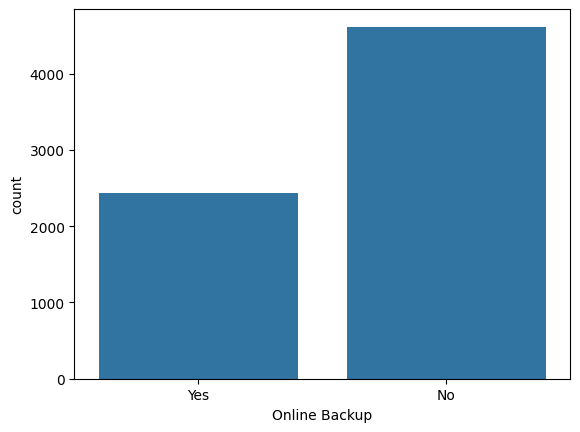

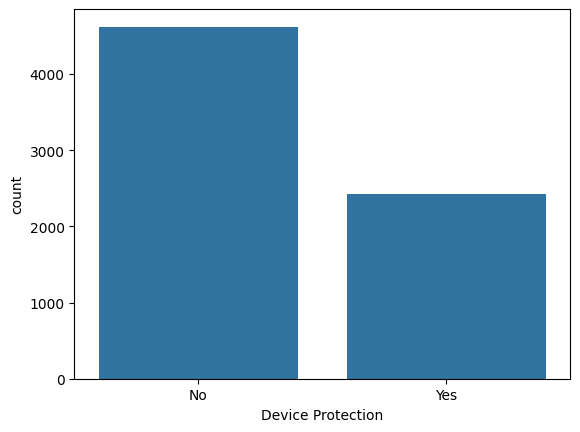

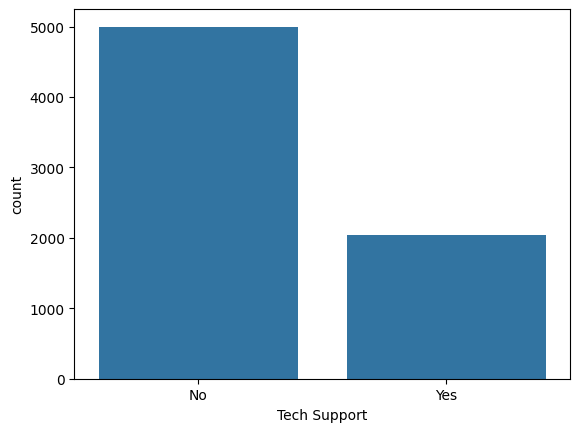

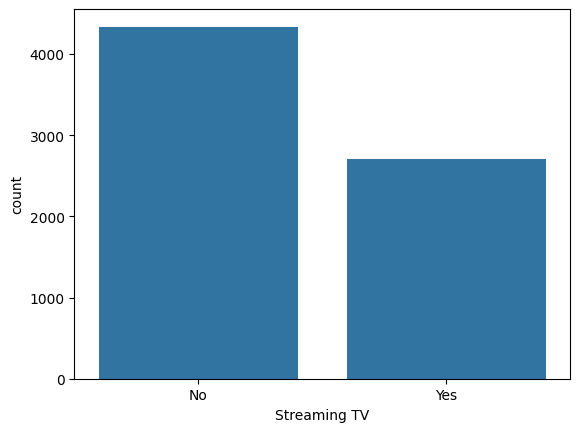

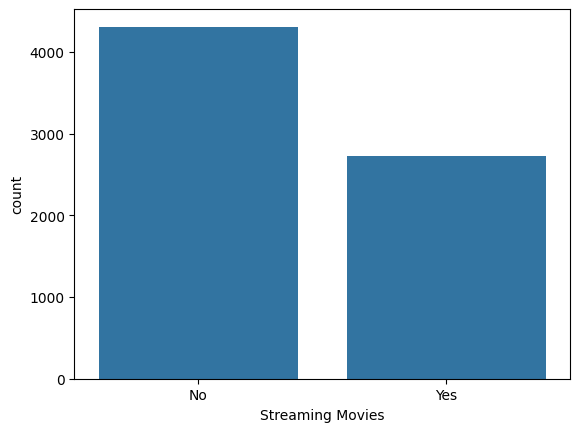

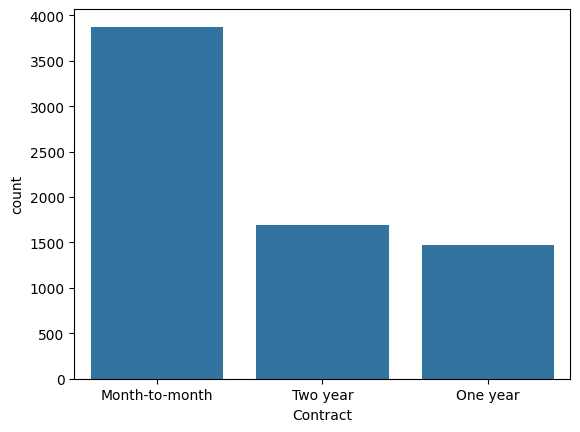

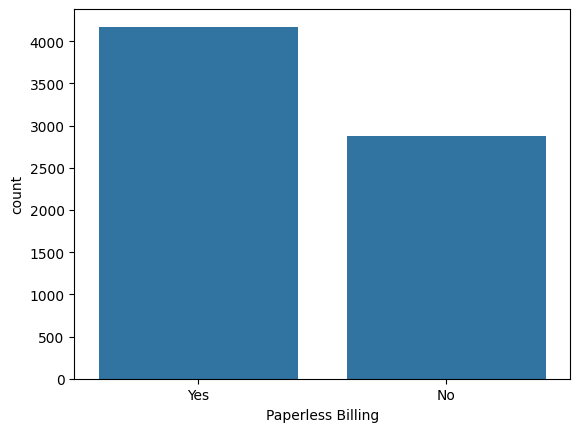

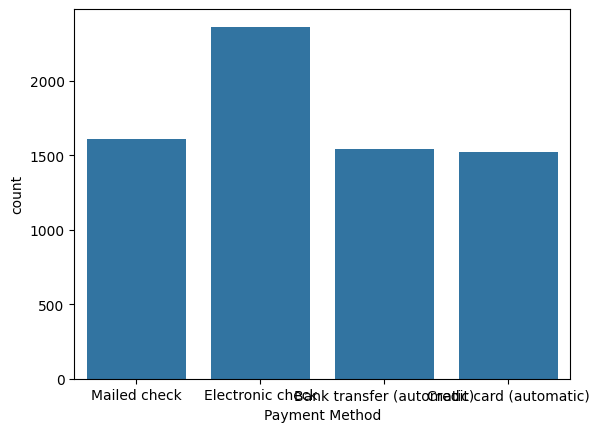

In [199]:
for col in cat_features:
  sns.countplot(x=col, data=df)
  plt.show()

In [200]:
for col in cat_features:
  print(pd.crosstab(df[col], df['Churn Value'], normalize='index') * 100)
  plt.show()

Churn Value             0          1
Senior Citizen                      
No              76.393832  23.606168
Yes             58.318739  41.681261
Churn Value          0          1
Partner                          
No           67.042021  32.957979
Yes          80.335097  19.664903
Churn Value          0          1
Dependents                       
No           67.448301  32.551699
Yes          93.484942   6.515058
Churn Value               0          1
Internet Service                      
DSL               81.040892  18.959108
Fiber optic       58.107235  41.892765
No                92.595020   7.404980
Churn Value              0          1
Online Security                      
No               68.670382  31.329618
Yes              85.388806  14.611194
Churn Value            0          1
Online Backup                      
No             70.827915  29.172085
Yes            78.468506  21.531494
Churn Value                0          1
Device Protection                      
No       

In [201]:
# Chi square test
from scipy.stats import chi2_contingency
for col in cat_features:
  contingency_table = pd.crosstab(df[col], df['Churn Value'])
  chi2, p, dof, expected = chi2_contingency(contingency_table)
  print(f'Feature: {col}')
  print(f"Chi-square statistic: {chi2}")
  print(f"P-value: {p}")


Feature: Senior Citizen
Chi-square statistic: 159.42630036838742
P-value: 1.510066805092378e-36
Feature: Partner
Chi-square statistic: 158.7333820309922
P-value: 2.1399113440759935e-36
Feature: Dependents
Chi-square statistic: 433.7343787644573
P-value: 2.5009723998553557e-96
Feature: Internet Service
Chi-square statistic: 732.309589667794
P-value: 9.571788222840544e-160
Feature: Online Security
Chi-square statistic: 205.63310416062058
P-value: 1.2320984831180024e-46
Feature: Online Backup
Chi-square statistic: 47.260854003612764
P-value: 6.214092807254819e-12
Feature: Device Protection
Chi-square statistic: 30.513394539261306
P-value: 3.315693222362861e-08
Feature: Tech Support
Chi-square statistic: 190.16684201526067
P-value: 2.9235674453140758e-43
Feature: Streaming TV
Chi-square statistic: 27.862522274233417
P-value: 1.3024835736732686e-07
Feature: Streaming Movies
Chi-square statistic: 26.25133601003847
P-value: 2.9974738476267514e-07
Feature: Contract
Chi-square statistic: 1184.5

In [202]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Senior Citizen     7043 non-null   object 
 1   Partner            7043 non-null   object 
 2   Dependents         7043 non-null   object 
 3   Tenure Months      7043 non-null   int64  
 4   Internet Service   7043 non-null   object 
 5   Online Security    7043 non-null   object 
 6   Online Backup      7043 non-null   object 
 7   Device Protection  7043 non-null   object 
 8   Tech Support       7043 non-null   object 
 9   Streaming TV       7043 non-null   object 
 10  Streaming Movies   7043 non-null   object 
 11  Contract           7043 non-null   object 
 12  Paperless Billing  7043 non-null   object 
 13  Payment Method     7043 non-null   object 
 14  Monthly Charges    7043 non-null   float64
 15  Total Charges      7032 non-null   float64
 16  Churn Value        7043 

In [203]:
def cramers_v(x, y):
    contingency_table = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    return np.sqrt((chi2 / n) / min(k - 1, r - 1))

In [204]:
# Measuring Strength with Cramers V
result = []
for col in cat_features:
  contingency_table = pd.crosstab(df[col], df['Churn Value'])
  chi2, p, dof, expected = chi2_contingency(contingency_table)
  n = contingency_table.sum().sum()
  r, k = contingency_table.shape
  v = np.sqrt((chi2 / n) / min(k - 1, r - 1))
  result.append({'Feature': col, 'CramersV': v})
cramers_df = pd.DataFrame(result).sort_values('CramersV', ascending=False)
print(cramers_df)

              Feature  CramersV
10           Contract  0.410116
3    Internet Service  0.322455
12     Payment Method  0.303359
2          Dependents  0.248161
11  Paperless Billing  0.191498
4     Online Security  0.170871
7        Tech Support  0.164319
0      Senior Citizen  0.150453
1             Partner  0.150126
5       Online Backup  0.081917
6   Device Protection  0.065821
8        Streaming TV  0.062897
9    Streaming Movies  0.061052


In [205]:
final_cat_features = df.select_dtypes(include='object').columns.tolist()

In [206]:
final_cat_features

['Senior Citizen',
 'Partner',
 'Dependents',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method']

In [207]:
# checking for col redundancy
from itertools import combinations
pairs = []
for col1, col2 in combinations(final_cat_features, 2):
  v = cramers_v(df[col1], df[col2])
  pairs.append({'feature1': col1, 'feature2': col2, 'CramersV': v})
pairs_df = pd.DataFrame(pairs).sort_values('CramersV', ascending=False)
print(pairs_df.head(15))

             feature1           feature2  CramersV
68       Streaming TV   Streaming Movies  0.532794
37   Internet Service       Streaming TV  0.442979
38   Internet Service   Streaming Movies  0.442924
59  Device Protection   Streaming Movies  0.401804
33   Internet Service    Online Security  0.394126
36   Internet Service       Tech Support  0.391367
58  Device Protection       Streaming TV  0.390567
34   Internet Service      Online Backup  0.381838
35   Internet Service  Device Protection  0.380757
40   Internet Service  Paperless Billing  0.378427
12            Partner         Dependents  0.363093
44    Online Security       Tech Support  0.354585
57  Device Protection       Tech Support  0.332983
41   Internet Service     Payment Method  0.313123
50      Online Backup  Device Protection  0.303232


In [208]:
# X and y features
x= df.drop(columns=['Churn Value'])
y = df['Churn Value']

In [209]:
cat_features = x.select_dtypes(include='object').columns.tolist()
binary_cols = [col for col in cat_features if x[col].nunique() == 2]
multi_cat_cols = [col for col in cat_features if x[col].nunique() > 2]
num_features = x.select_dtypes(include='number').columns.tolist()

In [210]:
multi_cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore' ))
    ])
binary_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder())
    ])
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
    ])

In [211]:
preprocessor = ColumnTransformer([
    ('Multi', multi_cat_pipeline, multi_cat_cols),
    ('Binary', binary_pipeline, binary_cols),
    ('Numeric', num_pipeline, num_features)
])

In [212]:
# Train_Test Split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

Stacking

In [213]:
# Stacking
base_learner = [
    ('dt', DecisionTreeClassifier(max_depth=5, criterion='entropy', class_weight='balanced', random_state=42)),
    ('svc', SVC(C=0.1, class_weight='balanced', random_state=42)),
    ('Knn', KNeighborsClassifier(7))
]
meta_learner = LogisticRegression(class_weight='balanced')
stacking_model = StackingClassifier(
    estimators=base_learner,
    final_estimator=meta_learner,
    cv=3
    )

In [214]:
# Full PipeLine
full_pipline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', stacking_model)
])

In [215]:
# Grid Search CV
grid_param = {
'model__dt__max_depth': [5, None],
'model__svc__C': [0.1, 1],
'model__Knn__n_neighbors': [5, 7]
}

model = RandomizedSearchCV(
    estimator=full_pipline,
    param_distributions=grid_param,
    n_iter=8,
    cv=3,
    scoring='f1',
    random_state=42
)

Traing and Prediciting

In [216]:
model.fit(x_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('Multi',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('encoder',
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               ['Internet '
                                                                                'Service',
                                                                                'Contract',
                                                                                'Payment '
                                                                                'Method']),
                                                                              ('Binary',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_freq...
                                                                                                     criterion='entropy',
                                                                                                     max_depth=5,
                                                                                                     random_state=42)),
                                                                             ('svc',
                                                                              SVC(C=0.1,
                                                                                  class_weight='balanced',
                                                                                  random_state=42)),
                                                                             ('Knn',
                                                                              KNeighborsClassifier(n_neighbors=7))],
                                                                 final_estimator=LogisticRegression(class_weight='balanced')))]),
                   n_iter=8,
                   param_distributions={'model__Knn__n_neighbors': [5, 7],
                                        'model__dt__max_depth': [5, None],
                                        'model__svc__C': [0.1, 1]},
                   random_state=42, scoring='f1')

In [217]:
y_pred= model.predict(x_test)

In [218]:
#Evaluating Stacking Model
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.7665010645848119
[[795 240]
 [ 89 285]]
              precision    recall  f1-score   support

           0       0.90      0.77      0.83      1035
           1       0.54      0.76      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.80      0.77      0.78      1409



In [219]:
# Save the fitted pipeline (preprocessing + stacking model)
best_pipeline = model.best_estimator_
joblib.dump(best_pipeline, 'churn_model.pkl')

['churn_model.pkl']

Random Forest

In [220]:
# Random Forest
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
    random_state=42
))
])

In [221]:
# Hyper parameter tunning for random forest
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 5, 10],
    'model__min_samples_leaf': [1, 2, 4, 10],
    'model__min_samples_split': [2, 5, 10],
    'model__class_weight': ['balanced', 'balanced_subsample']
}
rf_model = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter=100,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

Training and Predicting

In [222]:
# Fitting
rf_model.fit(x_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('Multi',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('encoder',
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               ['Internet '
                                                                                'Service',
                                                                                'Contract',
                                                                                'Payment '
                                                                                'Method']),
                                                                              ('Binary',
                                                                               Pipel...
                                                                                'Total '
                                                                                'Charges'])])),
                                             ('model',
                                              RandomForestClassifier(random_state=42))]),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'model__class_weight': ['balanced',
                                                                'balanced_subsample'],
                                        'model__max_depth': [None, 5, 10],
                                        'model__min_samples_leaf': [1, 2, 4,
                                                                    10],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [100, 200, 300]},
                   random_state=42, scoring='f1', verbose=1)

In [223]:
# Predicting
y_pred= rf_model.predict(x_test)

In [224]:
# Evaluating Random Forest
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(classification_report(y_test, y_pred))

[[825 210]
 [106 268]]
              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1035
           1       0.56      0.72      0.63       374

    accuracy                           0.78      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.78      0.78      1409



Bagging

In [225]:
# bagging classifier
bagging_model = BaggingClassifier(
   estimator=DecisionTreeClassifier(max_depth=5, criterion='entropy', class_weight='balanced', random_state=42),
    n_estimators=100,
)

In [226]:
# bagging pipeline
bagging_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', bagging_model)
])

Training and Predicting

In [227]:
# fitting
bagging_pipeline.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('Multi',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Internet Service',
                                                   'Contract',
                                                   'Payment Method']),
                                                 ('Binary',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder())])...
                                                   'Tech Support',
                                                   'Streaming TV',
                                                   'Streaming Movies',
                                                   'Paperless Billing']),
                                                 ('Numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Tenure Months',
                                                   'Monthly Charges',
                                                   'Total Charges'])])),
                ('model',
                 BaggingClassifier(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                                    criterion='entropy',
                                                                    max_depth=5,
                                                                    random_state=42),
                                   n_estimators=100))])

In [228]:
# predicting
y_pred = bagging_pipeline.predict(x_test)

In [229]:
#Evaluating Bagging model
cm= confusion_matrix(y_test, y_pred)
print(cm)
print(classification_report(y_test, y_pred))

[[770 265]
 [ 80 294]]
              precision    recall  f1-score   support

           0       0.91      0.74      0.82      1035
           1       0.53      0.79      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.76      0.77      1409



XG_Boost

In [230]:
# XGboost Classifier
model = XGBClassifier()

In [231]:
# XG_Boost Pipeline
xg_pipeline= Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

In [232]:
# XG_Boost Hyper parameter tunning
param_grid = {
    # 1. Learning Speed & Ensemble Size
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],

    # 2. Tree Complexity
    'model__max_depth': [3, 5, 7],
    'model__min_child_weight': [1, 3, 5],

    # 3. Stochastic Sampling (Prevents Overfitting)
    'model__subsample': [0.7, 0.8, 0.9],
    'model__colsample_bytree': [0.7, 0.8, 0.9],

    # 4. Regularization
    'model__gamma': [0, 0.1, 0.2]
}
xg_model = RandomizedSearchCV(
    estimator=xg_pipeline,
    param_distributions=param_grid,
    n_iter=8,
    cv=StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    ),
    scoring='f1',
    random_state=42
)

Training and Predicting

In [233]:
# Fitting
xg_model.fit(x_train, y_train)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('Multi',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('encoder',
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               ['Internet '
                                                                                'Service',
                                                                                'Contract',
                                                                                'Payment '
                                                                                'Method']),
                                                                              ('Binary',
                                                                               Pipel...
                                                            n_estimators=None,
                                                            n_jobs=None,
                                                            num_parallel_tree=None, ...))]),
                   n_iter=8,
                   param_distributions={'model__colsample_bytree': [0.7, 0.8,
                                                                    0.9],
                                        'model__gamma': [0, 0.1, 0.2],
                                        'model__learning_rate': [0.01, 0.05,
                                                                 0.1, 0.2],
                                        'model__max_depth': [3, 5, 7],
                                        'model__min_child_weight': [1, 3, 5],
                                        'model__n_estimators': [100, 200, 300],
                                        'model__subsample': [0.7, 0.8, 0.9]},
                   random_state=42, scoring='f1')

In [234]:
# Predicting
y_pred = xg_model.predict(x_test)

In [235]:
# Evaluating XG_Boost Model
cm= confusion_matrix(y_test, y_pred)
print(cm)
print(classification_report(y_test, y_pred))

[[918 117]
 [174 200]]
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.53      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



In [241]:
!pip install gradio -q

UI for XG_Boost_MODEL

In [242]:
import gradio as gr
import pandas as pd

best_xg_pipeline = xg_model.best_estimator_  # in-memory, no pickle load involved

def predict_churn(*args):
    # Rebuild input row in the exact column order used during training
    input_dict = dict(zip(x.columns, args))
    input_df = pd.DataFrame([input_dict])

    # Cast numeric columns back to numeric (Gradio can pass them as float)
    for col in num_features:
        input_df[col] = pd.to_numeric(input_df[col])

    pred = best_xg_pipeline.predict(input_df)[0]
    proba = best_xg_pipeline.predict_proba(input_df)[0][1]

    label = "⚠️ Likely to Churn" if pred == 1 else "✅ Likely to Stay"
    return f"{label}\n\nChurn probability: {proba:.1%}"

# Build one Gradio input component per column, matching its type
inputs = []
for col in x.columns:
    if col in num_features:
        col_min = float(x[col].min())
        col_max = float(x[col].max())
        col_mean = float(x[col].mean())
        inputs.append(
            gr.Slider(minimum=col_min, maximum=col_max, value=col_mean, label=col)
        )
    else:
        # binary_cols and multi_cat_cols both become dropdowns
        choices = sorted(x[col].dropna().unique().tolist())
        inputs.append(gr.Dropdown(choices=choices, value=choices[0], label=col))

demo = gr.Interface(
    fn=predict_churn,
    inputs=inputs,
    outputs=gr.Textbox(label="Prediction"),
    title="Customer Churn Predictor",
    description="Fill in customer details to predict churn risk.",
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e4b8d494b767ffb2ef.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
